# Zadanie 3: Model surogatowy ODE

W tym zadaniu stworzymy model surogatowy ODE dla zjawiska dyfuzji-reakcji, eliminując zmienną przestrzenną. Porównamy wyniki tego modelu z oryginalnym modelem czasowo-przestrzennym. Następnie, nauczymy sieć neuronową na danych z oryginalnego modelu i porównamy jej predykcje.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from solvers import run_simulation
import torch
import torch.nn as nn

## 1. Model oryginalny (PDE) i Model surogatowy (ODE)

Oryginalny model to równanie różniczkowe cząstkowe (PDE) dyfuzji-reakcji:
$$ \frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} + (p + qu)(1-u) $$

Aby stworzyć model surogatowy, uśredniamy równanie po zmiennej przestrzennej $x \in [0, 1]$. Przy warunkach brzegowych Neumanna, człon dyfuzyjny $\int_0^1 D u_{xx} dx = D[u_x]_0^1 = 0$. Upraszczając $\mathbb{E}[R(u)] \approx R(\mathbb{E}[u])$, gdzie $U(t) = \mathbb{E}[u(x,t)] = \int_0^1 u(x,t) dx$, otrzymujemy równanie różniczkowe zwyczajne (ODE):
$$ \frac{dU}{dt} = (p + qU)(1-U) $$

In [3]:
# Parametry symulacji
D_param = 0.1
p_param = 0.01
q_param = 1.0
tend = 15.0
nx = 100
dt = 1e-3

# Uruchomienie symulacji oryginalnego modelu PDE
x_pde, u_pde_final, _ = run_simulation(
    solver='crank-nicolson',
    nx=nx,
    dt=dt,
    tend=tend,
    D=D_param,
    p=p_param,
    q=q_param,
    init_kind='gaussian'
)

# Obliczenie średniej z modelu PDE w czasie
num_steps = int(tend / dt)
u_pde_mean_over_time = np.zeros(num_steps)
u_current = run_simulation(solver='crank-nicolson', nx=nx, dt=dt, tend=0, D=D_param, p=p_param, q=q_param, init_kind='gaussian')[1]
u_pde_mean_over_time[0] = np.mean(u_current)

# Re-use the solver's internal loop logic to get snapshots
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from solvers import _neumann_laplacian, reaction
dx = 1.0 / (nx - 1)
A = _neumann_laplacian(nx, dx)
M_l = sp.eye(nx) - 0.5 * dt * D_param * A
M_r = sp.eye(nx) + 0.5 * dt * D_param * A
for i in range(1, num_steps):
    Ru = reaction(u_current, p_param, q_param)
    rhs = M_r.dot(u_current) + dt * Ru
    u_current = spla.spsolve(M_l, rhs)
    u_pde_mean_over_time[i] = np.mean(u_current)

t_pde = np.linspace(0, tend, num_steps)

# Rozwiązanie modelu surogatowego ODE
def surrogate_ode(t, U):
    return (p_param + q_param * U) * (1 - U)

u0_pde_mean = np.mean(run_simulation(solver='crank-nicolson', nx=nx, dt=dt, tend=0, D=D_param, p=p_param, q=q_param, init_kind='gaussian')[1])
t_span_ode = [0, tend]

# Pomiar czasu inferencji dla ODE
import time
t_ode_start = time.perf_counter()
sol_ode = solve_ivp(surrogate_ode, t_span_ode, [u0_pde_mean], dense_output=True)
t_ode_end = time.perf_counter()
ode_inference_time = t_ode_end - t_ode_start

t_ode = np.linspace(0, tend, 100)
u_ode = sol_ode.sol(t_ode).T

print(f"Czas inferencji dla modelu ODE: {ode_inference_time * 1000:.4f} ms")

Czas inferencji dla modelu ODE: 1.2921 ms


## 3. Sieć neuronowa jako model surogatowy

Teraz nauczymy prostą sieć neuronową, aby przewidywała ewolucję średniej wartości $U(t)$ na podstawie danych z modelu PDE.

In [4]:
import time

# Przygotowanie danych do uczenia
X_train_raw = torch.tensor(t_pde, dtype=torch.float32).view(-1, 1)
y_train = torch.tensor(u_pde_mean_over_time, dtype=torch.float32).view(-1, 1)

# Normalizacja wejścia (czasu)
t_mean = X_train_raw.mean()
t_std = X_train_raw.std()
X_train = (X_train_raw - t_mean) / t_std

# Definicja modelu sieci neuronowej
class SurrogateNN(nn.Module):
    def __init__(self):
        super(SurrogateNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SurrogateNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Increased LR slightly

# Proces uczenia
epochs = 2000 # Increased epochs
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Predykcje modelu i pomiar czasu inferencji
t_inference_start = time.perf_counter()
with torch.no_grad():
    # Normalizacja danych testowych tymi samymi parametrami
    t_ode_tensor = torch.tensor(t_ode, dtype=torch.float32).view(-1, 1)
    t_ode_norm = (t_ode_tensor - t_mean) / t_std
    u_nn_pred = model(t_ode_norm).numpy()
t_inference_end = time.perf_counter()

inference_time = t_inference_end - t_inference_start
print(f"\nCzas inferencji dla prostego modelu NN: {inference_time * 1000:.4f} ms")

Epoch [200/2000], Loss: 0.000030
Epoch [400/2000], Loss: 0.000017
Epoch [400/2000], Loss: 0.000017
Epoch [600/2000], Loss: 0.000011
Epoch [600/2000], Loss: 0.000011
Epoch [800/2000], Loss: 0.000007
Epoch [800/2000], Loss: 0.000007
Epoch [1000/2000], Loss: 0.000006
Epoch [1000/2000], Loss: 0.000006
Epoch [1200/2000], Loss: 0.000005
Epoch [1200/2000], Loss: 0.000005
Epoch [1400/2000], Loss: 0.000004
Epoch [1400/2000], Loss: 0.000004
Epoch [1600/2000], Loss: 0.000004
Epoch [1600/2000], Loss: 0.000004
Epoch [1800/2000], Loss: 0.000003
Epoch [1800/2000], Loss: 0.000003
Epoch [2000/2000], Loss: 0.000003

Czas inferencji dla prostego modelu NN: 0.8670 ms
Epoch [2000/2000], Loss: 0.000003

Czas inferencji dla prostego modelu NN: 0.8670 ms


## 4. Porównanie wszystkich modeli

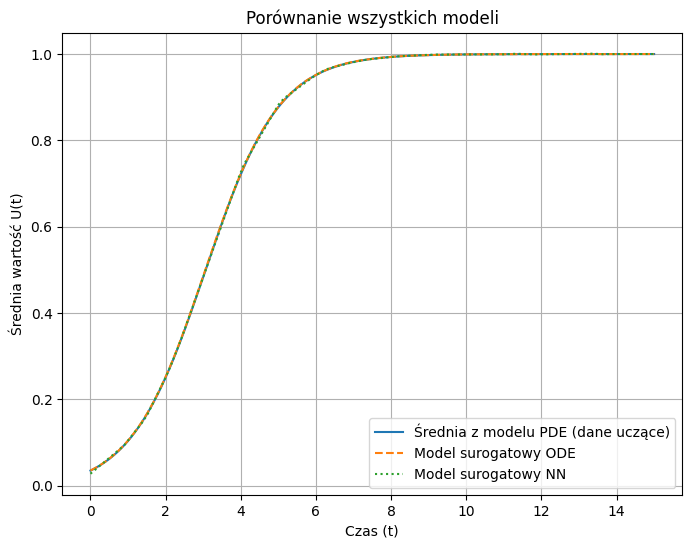

Zapisano czasy inferencji do c:\Users\looxx\Desktop\studia\informatyka_systemow_zlozonych\ISZ-Project\zad3\inference_times.txt


In [5]:
import os
out_dir = os.path.join(os.getcwd(), "zad3_figs")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "comparison_plot.png")

plt.figure(figsize=(8, 6))
plt.plot(t_pde, u_pde_mean_over_time, label='Średnia z modelu PDE (dane uczące)')
plt.plot(t_ode, u_ode, label='Model surogatowy ODE', linestyle='--')
plt.plot(t_ode, u_nn_pred, label='Model surogatowy NN', linestyle=':')
plt.title('Porównanie wszystkich modeli')
plt.xlabel('Czas (t)')
plt.ylabel('Średnia wartość U(t)')
plt.grid(True)
plt.legend()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

# Zapisz czasy inferencji do pliku tekstowego
times_file = os.path.join(os.getcwd(), "inference_times.txt")
with open(times_file, 'w') as f:
    f.write(f"Czas inferencji dla modelu ODE: {ode_inference_time * 1000:.4f} ms\n")
    f.write(f"Czas inferencji dla prostego modelu NN: {inference_time * 1000:.4f} ms\n")
print(f"Zapisano czasy inferencji do {times_file}")

## 5. Ulepszony model surogatowy NN (uczenie na wielu symulacjach)

Aby stworzyć model, który generalizuje, musimy nauczyć go na danych z wielu symulacji z różnymi parametrami `D`, `p`, `q`.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))
from solvers import run_simulation, reaction, _neumann_laplacian
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

def generate_dataset(num_simulations=50, tend=15.0, dt=1e-3, nx=100):
    """Generuje zbiór danych z wielu symulacji PDE z losowymi parametrami."""
    input_data = []
    output_data = []
    
    rng = np.random.default_rng(42)
    
    for i in range(num_simulations):
        # Losowe parametry fizyczne
        D = rng.uniform(0.01, 1.0)
        p = rng.uniform(0.001, 0.1)
        q = rng.uniform(0.1, 10.0)
        
        print(f"Symulacja {i+1}/{num_simulations} (D={D:.2f}, p={p:.3f}, q={q:.2f})")

        # Symulacja i zbieranie danych
        num_steps = int(tend / dt)
        t_series = np.linspace(0, tend, num_steps)
        
        u_current = run_simulation(solver='crank-nicolson', nx=nx, dt=dt, tend=0, D=D, p=p, q=q, init_kind='gaussian')[1]
        
        dx = 1.0 / (nx - 1)
        A = _neumann_laplacian(nx, dx)
        M_l = sp.eye(nx) - 0.5 * dt * D * A
        M_r = sp.eye(nx) + 0.5 * dt * D * A

        for step in range(num_steps):
            u_mean = np.mean(u_current)
            
            # Wejście: (t, D, p, q)
            input_data.append([t_series[step], D, p, q])
            # Wyjście: U(t)
            output_data.append([u_mean])
            
            Ru = reaction(u_current, p, q)
            rhs = M_r.dot(u_current) + dt * Ru
            u_current = spla.spsolve(M_l, rhs)

    return np.array(input_data), np.array(output_data)

# Generowanie danych (może chwilę potrwać)
# Zmniejszono liczbę symulacji do 20 dla szybkości demonstracji
X_multi, y_multi = generate_dataset(num_simulations=20, tend=15.0, dt=1e-3) 

print(f"Wygenerowano {X_multi.shape[0]} punktów danych.")

Symulacja 1/20 (D=0.78, p=0.044, q=8.60)
Symulacja 2/20 (D=0.70, p=0.010, q=9.76)
Symulacja 2/20 (D=0.70, p=0.010, q=9.76)
Symulacja 3/20 (D=0.76, p=0.079, q=1.37)
Symulacja 3/20 (D=0.76, p=0.079, q=1.37)
Symulacja 4/20 (D=0.46, p=0.038, q=9.27)
Symulacja 4/20 (D=0.46, p=0.038, q=9.27)
Symulacja 5/20 (D=0.65, p=0.082, q=4.49)
Symulacja 5/20 (D=0.65, p=0.082, q=4.49)
Symulacja 6/20 (D=0.23, p=0.056, q=0.73)
Symulacja 6/20 (D=0.23, p=0.056, q=0.73)
Symulacja 7/20 (D=0.83, p=0.064, q=7.61)
Symulacja 7/20 (D=0.83, p=0.064, q=7.61)
Symulacja 8/20 (D=0.36, p=0.097, q=8.94)
Symulacja 8/20 (D=0.36, p=0.097, q=8.94)
Symulacja 9/20 (D=0.78, p=0.020, q=4.72)
Symulacja 9/20 (D=0.78, p=0.020, q=4.72)
Symulacja 10/20 (D=0.05, p=0.016, q=6.86)
Symulacja 10/20 (D=0.05, p=0.016, q=6.86)
Symulacja 11/20 (D=0.75, p=0.097, q=3.33)
Symulacja 11/20 (D=0.75, p=0.097, q=3.33)
Symulacja 12/20 (D=0.38, p=0.047, q=1.98)
Symulacja 12/20 (D=0.38, p=0.047, q=1.98)
Symulacja 13/20 (D=0.14, p=0.048, q=2.35)
Symulacja

### Uczenie ulepszonego modelu

In [7]:
# Podział na zbiór uczący i walidacyjny
perm = np.random.default_rng(0).permutation(len(X_multi))
n_train = int(0.8 * len(X_multi))
train_idx, val_idx = perm[:n_train], perm[n_train:]

X_train_np, y_train_np = X_multi[train_idx], y_multi[train_idx]
X_val_np, y_val_np = X_multi[val_idx], y_multi[val_idx]

# Normalizacja danych
X_mean, X_std = X_train_np.mean(axis=0), X_train_np.std(axis=0) + 1e-8
y_mean, y_std = y_train_np.mean(axis=0), y_train_np.std(axis=0) + 1e-8

X_train = torch.tensor((X_train_np - X_mean) / X_std, dtype=torch.float32)
y_train = torch.tensor((y_train_np - y_mean) / y_std, dtype=torch.float32)
X_val = torch.tensor((X_val_np - X_mean) / X_std, dtype=torch.float32)
y_val = torch.tensor((y_val_np - y_mean) / y_std, dtype=torch.float32)

# Model NN z 4 wejściami
class GeneralSurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

# Uczenie modelu
model_general = GeneralSurrogateNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_general.parameters(), lr=1e-3, weight_decay=1e-5)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)

epochs = 100
for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_general(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

Epoch [10/100], Loss: 0.000440
Epoch [20/100], Loss: 0.000187
Epoch [20/100], Loss: 0.000187
Epoch [30/100], Loss: 0.002824
Epoch [30/100], Loss: 0.002824
Epoch [40/100], Loss: 0.001127
Epoch [40/100], Loss: 0.001127
Epoch [50/100], Loss: 0.000658
Epoch [50/100], Loss: 0.000658
Epoch [60/100], Loss: 0.000809
Epoch [60/100], Loss: 0.000809
Epoch [70/100], Loss: 0.000177
Epoch [70/100], Loss: 0.000177
Epoch [80/100], Loss: 0.000319
Epoch [80/100], Loss: 0.000319
Epoch [90/100], Loss: 0.000464
Epoch [90/100], Loss: 0.000464
Epoch [100/100], Loss: 0.000202
Epoch [100/100], Loss: 0.000202


### Walidacja nowego modelu

Test na parametrach: D=0.02, p=0.079, q=6.68


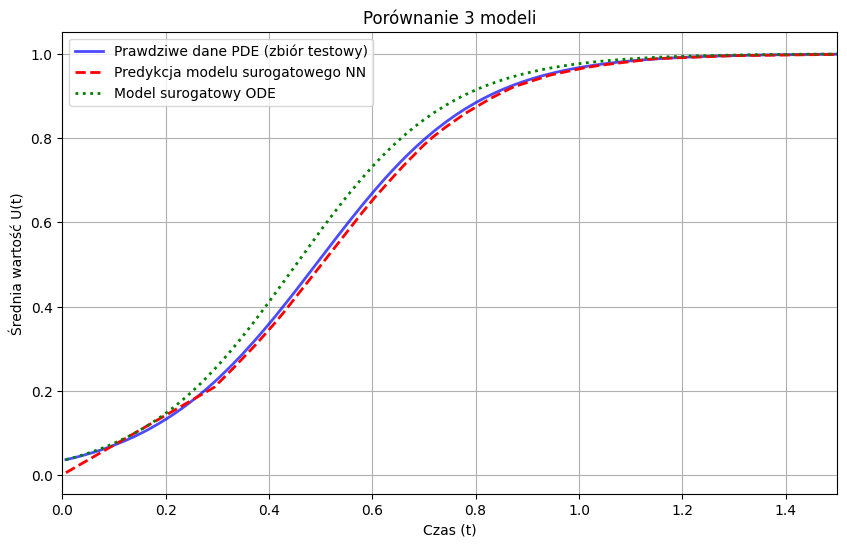

In [12]:
# Wybierz losową symulację z zestawu walidacyjnego do wizualizacji
# Bierzemy pierwszy zestaw unikalnych parametrów ze zbioru walidacyjnego
unique_params = np.unique(X_val_np[:, 1:], axis=0)
D_test, p_test, q_test = unique_params[0]

print(f"Test na parametrach: D={D_test:.2f}, p={p_test:.3f}, q={q_test:.2f}")

# Znajdź wszystkie punkty z tej samej symulacji w zbiorze walidacyjnym
mask = (np.abs(X_val_np[:, 1] - D_test) < 1e-6) & \
       (np.abs(X_val_np[:, 2] - p_test) < 1e-6) & \
       (np.abs(X_val_np[:, 3] - q_test) < 1e-6)
X_test_sample = X_val_np[mask]
y_test_sample = y_val_np[mask]

# Sortowanie po czasie
time_order = np.argsort(X_test_sample[:, 0])
X_test_sample = X_test_sample[time_order]
y_test_sample = y_test_sample[time_order]

# Predykcja modelu NN
X_test_norm = torch.tensor((X_test_sample - X_mean) / X_std, dtype=torch.float32)
with torch.no_grad():
    y_pred_norm = model_general(X_test_norm)
y_pred = y_pred_norm.numpy() * y_std + y_mean

# Rozwiązanie ODE dla tych parametrów
def ode_func_test(t, U):
    return (p_test + q_test * U) * (1 - U)

t_eval = X_test_sample[:, 0]
t_span = [t_eval[0], t_eval[-1]]
u0 = [y_test_sample[0][0]] # y_test_sample is (N, 1)

# Solve ODE
sol_ode_test = solve_ivp(ode_func_test, t_span, u0, t_eval=t_eval)
u_ode_test = sol_ode_test.y.T

# Porównanie na wykresie
plt.figure(figsize=(10, 6))
plt.plot(X_test_sample[:, 0], y_test_sample, label='Prawdziwe dane PDE (zbiór testowy)', color='blue', linewidth=2, alpha=0.7)
plt.plot(X_test_sample[:, 0], y_pred, label='Predykcja modelu surogatowego NN', color='red', linestyle='--', linewidth=2)
plt.plot(sol_ode_test.t, u_ode_test, label='Model surogatowy ODE', color='green', linestyle=':', linewidth=2)

plt.title('Porównanie 3 modeli')
plt.xlabel('Czas (t)')
plt.ylabel('Średnia wartość U(t)')
plt.legend()
plt.xlim(0, 1.5)
plt.grid(True)
plt.savefig(os.path.join(out_dir, "comparison_3_models_validation.png"), dpi=300, bbox_inches='tight')
plt.show()